# 🧪 Augmented Dickey-Fuller (ADF) Test

The **Augmented Dickey-Fuller (ADF)** test is the most widely used statistical test to determine if a time series is **Stationary**.

In technical terms, it tests for the presence of a **Unit Root**. If a series has a unit root, it shows a systematic pattern that is unpredictable (like a random walk with drift), making it **Non-Stationary**.



---

## 1. The Hypotheses
Unlike most logic where we try to "prove" something is true, in statistical testing, we try to **reject** the opposite.

* **Null Hypothesis ($H_0$):** The time series **HAS** a unit root.
    * *Meaning:* The data is **Non-Stationary** (It is dependent on previous values, has a trend, etc.).
* **Alternative Hypothesis ($H_1$):** The time series does **NOT** have a unit root.
    * *Meaning:* The data is **Stationary**.

> **The Goal:** We want to **Reject the Null Hypothesis ($H_0$)**.

---

## 2. Interpreting the Output
When you run the test, you get two main numbers: the **P-Value** and the **Test Statistic**.

### A. The P-Value Rule (The Shortcut)
This is the easiest way to read the result.
* **If P-Value $\le$ 0.05:**
    * **Result:** Reject $H_0$.
    * **Conclusion:** The data is **Stationary**. ✅
* **If P-Value > 0.05:**
    * **Result:** Fail to reject $H_0$.
    * **Conclusion:** The data is **Non-Stationary**. ❌

### B. The Test Statistic Rule (The Precision)
Sometimes the p-value is borderline. You can compare the **ADF Statistic** to the **Critical Values** (1%, 5%, 10%).
* The ADF Statistic should be **more negative** than the Critical Value.
* *Example:*
    * ADF Statistic: `-3.5`
    * 5% Critical Value: `-2.9`
    * Since `-3.5` < `-2.9`, we reject the null hypothesis.

---

## 3. Why "Augmented"?
The original "Dickey-Fuller" test assumed that the error terms were not correlated. However, in real-world data, today's error is often correlated with yesterday's error (autocorrelation).
* **Augmented:** The test adds "lagged differences" to the equation to account for this higher-order correlation, making the test strictly stronger and more reliable for complex real-world data.

#### 1) Importing Necessary Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.graphics.tsaplots import month_plot, quarter_plot

#### 2) Loading Data:

In [2]:
airline =  pd.read_csv('airline_passengers.csv', index_col= 0, parse_dates= True)
births = pd.read_csv('DailyTotalFemaleBirths.csv', index_col= 0, parse_dates= True)

In [3]:
airline.head()

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [4]:
births.head()

,Births
Date,
1959-01-01,35
1959-01-02,32
1959-01-03,30
1959-01-04,31
1959-01-05,44


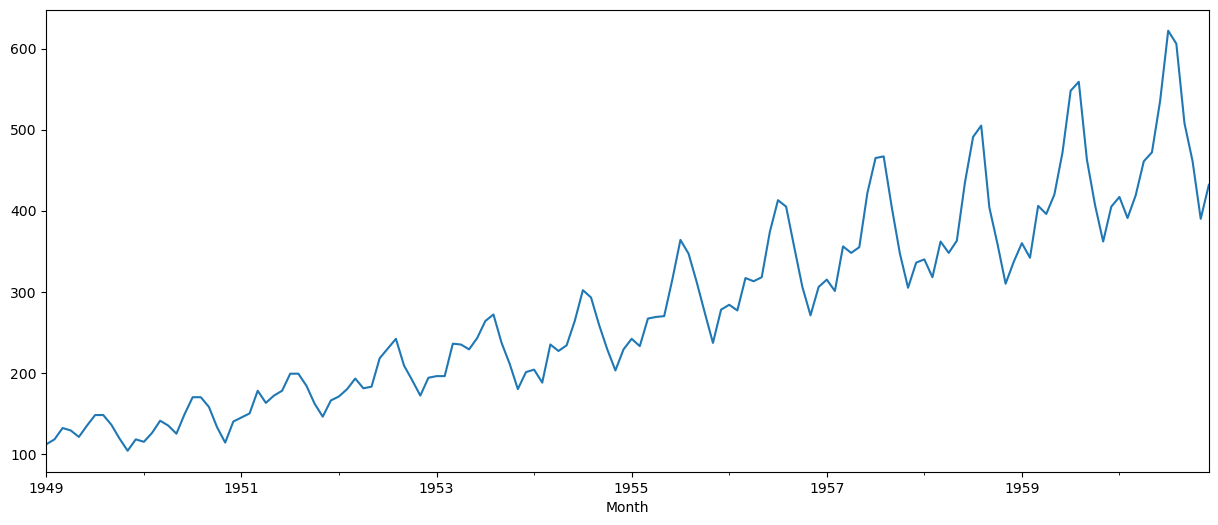

In [5]:
# Plotting Data:

airline['Thousands of Passengers'].plot(kind= 'line', figsize= (15,6))
plt.show()

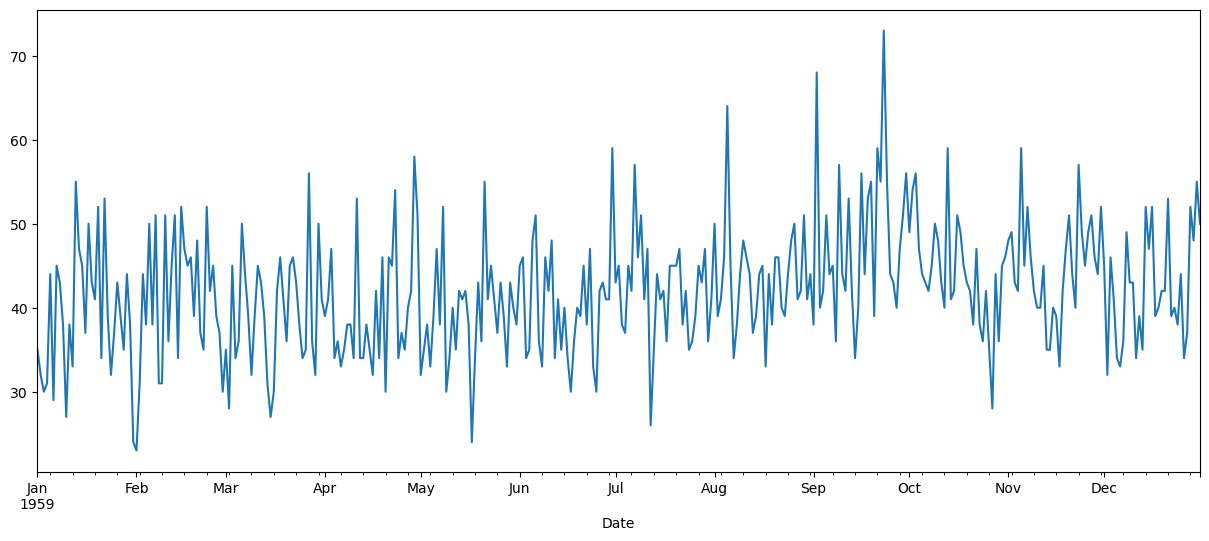

In [6]:
# Plotting Data:

births['Births'].plot(kind= 'line', figsize= (15,6))
plt.show()

##### Adding Index Frequency to Data:

In [7]:
airline.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

In [8]:
airline.index.freq = 'MS'

In [9]:
births.index

DatetimeIndex(['1959-01-01', '1959-01-02', '1959-01-03', '1959-01-04',
               '1959-01-05', '1959-01-06', '1959-01-07', '1959-01-08',
               '1959-01-09', '1959-01-10',
               ...
               '1959-12-22', '1959-12-23', '1959-12-24', '1959-12-25',
               '1959-12-26', '1959-12-27', '1959-12-28', '1959-12-29',
               '1959-12-30', '1959-12-31'],
              dtype='datetime64[ns]', name='Date', length=365, freq=None)

In [10]:
births.index.freq = 'D'

#### 3) Augmented Dickey-Fuller Test for Stationarity:

In [11]:
adfuller(x= airline['Thousands of Passengers'])

(np.float64(0.8153688792060472),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.6929308390189))

In [12]:
adfuller(x= births['Births'])

(np.float64(-4.808291253559765),
 np.float64(5.2434129901498554e-05),
 6,
 358,
 {'1%': np.float64(-3.448748905151901),
  '5%': np.float64(-2.8696473721448728),
  '10%': np.float64(-2.5710891239349585)},
 np.float64(2343.8290926464197))

##### Creating a Function to Display Results of Augmented Dickey-Fuller Test:

In [13]:
help(adfuller)

Help on function adfuller in module statsmodels.tsa.stattools:

adfuller(x, maxlag: 'int | None' = None, regression='c', autolag='AIC', store=False, regresults=False)
    Augmented Dickey-Fuller unit root test.

    The Augmented Dickey-Fuller test can be used to test for a unit root in a
    univariate process in the presence of serial correlation.

    Parameters
    ----------
    x : array_like, 1d
        The data series to test.
    maxlag : {None, int}
        Maximum lag which is included in test, default value of
        12*(nobs/100)^{1/4} is used when ``None``.
    regression : {"c","ct","ctt","n"}
        Constant and trend order to include in regression.

        * "c" : constant only (default).
        * "ct" : constant and trend.
        * "ctt" : constant, and linear and quadratic trend.
        * "n" : no constant, no trend.

    autolag : {"AIC", "BIC", "t-stat", None}
        Method to use when automatically determining the lag length among the
        values 0, 1, .

In [16]:
def dickey_fuller_result(series):
    """
    Function To Perform Augmenter Dickey-Fuller Test and Display Results.
    """
    
    result= adfuller(series.dropna())
    
    labels = ["Test Statistics", "p-Value", "No. of Lags", "No. of Observations"]
    
    output = pd.Series(result[0:4], index= labels)
    
    for key,value in result[4].items():
        output[f"Critical Value {key}"] = value
        
    print(output)
    
    print("\n")
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis.")
        print("Reject the null hypothesis.")
        print("Data has no unit root and is stationary.")
    else:
        print("Weak evidence against the null hypothesis.")
        print("Fail to reject the null hypothesis.")
        print("Data has a unit root and is non-stationary.")

In [17]:
dickey_fuller_result(airline['Thousands of Passengers'])

Test Statistics          0.815369
p-Value                  0.991880
No. of Lags             13.000000
No. of Observations    130.000000
Critical Value 1%       -3.481682
Critical Value 5%       -2.884042
Critical Value 10%      -2.578770
dtype: float64


Weak evidence against the null hypothesis.
Fail to reject the null hypothesis.
Data has a unit root and is non-stationary.


In [18]:
dickey_fuller_result(births['Births'])

Test Statistics         -4.808291
p-Value                  0.000052
No. of Lags              6.000000
No. of Observations    358.000000
Critical Value 1%       -3.448749
Critical Value 5%       -2.869647
Critical Value 10%      -2.571089
dtype: float64


Strong evidence against the null hypothesis.
Reject the null hypothesis.
Data has no unit root and is stationary.


# 🔗 Granger Causality Test

**"Correlation is not Causality"** is the most famous phrase in statistics. The **Granger Causality Test** is the tool we use to see if we can establish a directional, predictive relationship between two time series.

**Crucial Definition:**
Granger Causality is **NOT** physical or philosophical causality (e.g., "Rain causes Mud").
Instead, it is **Predictive Causality**: *"Does knowing the past values of Time Series X help me predict the future values of Time Series Y better than just using Y's own history?"*



---

## 1. The Logic (The Battle of Two Models)
To test if $X$ Granger-causes $Y$, we compare two regression models:

1.  **Restricted Model:** We try to predict $Y_t$ using **only** past values of $Y$ (Lags of $Y$).
    $$Y_t = A \cdot Y_{t-1} + B \cdot Y_{t-2} + \dots + \text{Error}$$
2.  **Unrestricted Model:** We try to predict $Y_t$ using past values of $Y$ **AND** past values of $X$.
    $$Y_t = A \cdot Y_{t-1} + \dots + \beta \cdot X_{t-1} + \dots + \text{Error}$$

**The Test:**
We check if the coefficients for $X$ ($\beta$) are statistically significant. If adding $X$ significantly reduces the prediction error compared to using $Y$ alone, we say **"X Granger-causes Y"**.

---

## 2. The Hypotheses
This test uses the F-test framework.

* **Null Hypothesis ($H_0$):** The coefficients of past values of $X$ are zero.
    * *Meaning:* Past values of $X$ do **NOT** help predict $Y$. ($X$ does not Granger-cause $Y$).
* **Alternative Hypothesis ($H_1$):** The coefficients are not zero.
    * *Meaning:* Past values of $X$ **DO** help predict $Y$. ($X$ Granger-causes $Y$).

**Interpretation:**
* **P-Value < 0.05:** Reject $H_0$. **$X$ Granger-causes $Y$.** ✅
* **P-Value > 0.05:** Fail to reject $H_0$. **No relationship found.** ❌

---

## 3. Directionality Matters
Granger Causality is **unidirectional**.
* It is possible that $X \rightarrow Y$ (X predicts Y).
* It is possible that $Y \rightarrow X$ (Y predicts X).
* It is possible that $X \leftrightarrow Y$ (Bi-directional causality, known as a "feedback loop").

Therefore, you typically run the test **twice**: once for $X \rightarrow Y$ and once for $Y \rightarrow X$.

## ⚠️ Important Prerequisites
1.  **Stationarity:** Both time series **MUST** be stationary before running this test. If they are not, you must difference them first.
2.  **Lag Selection:** The result is very sensitive to the number of lags you choose. A relationship might exist at Lag 4 (4 months ago) but not at Lag 1 (last month).

In [19]:
df = pd.read_csv('samples.csv', index_col= 0, parse_dates= True)

In [20]:
df.head()

,a,b,c,d
1950-01-01,36,27,0,67
1950-02-01,58,22,3,31
1950-03-01,61,17,5,67
1950-04-01,37,15,8,47
1950-05-01,66,13,8,62


In [21]:
df.shape

(120, 4)

In [23]:
df.index

DatetimeIndex(['1950-01-01', '1950-02-01', '1950-03-01', '1950-04-01',
               '1950-05-01', '1950-06-01', '1950-07-01', '1950-08-01',
               '1950-09-01', '1950-10-01',
               ...
               '1959-03-01', '1959-04-01', '1959-05-01', '1959-06-01',
               '1959-07-01', '1959-08-01', '1959-09-01', '1959-10-01',
               '1959-11-01', '1959-12-01'],
              dtype='datetime64[ns]', length=120, freq=None)

In [24]:
df.index.freq = 'MS'

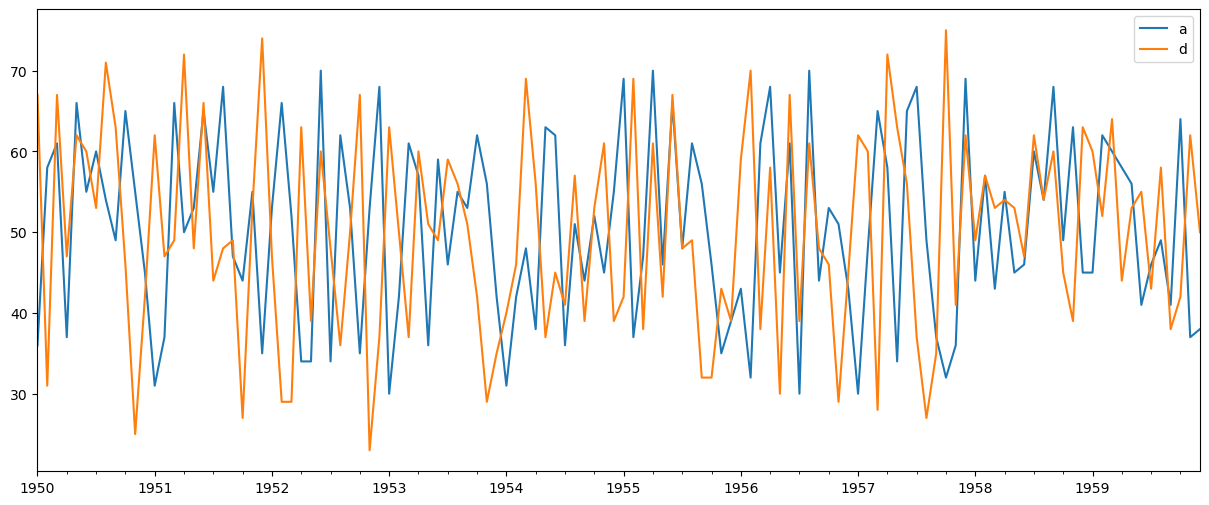

In [25]:
# Plotting 'a' and 'd':

df['a'].plot(kind= 'line', figsize= (15,6), label= 'a', legend= True)
df['d'].plot(kind= 'line', figsize= (15,6), label= 'd', legend= True)
plt.show()

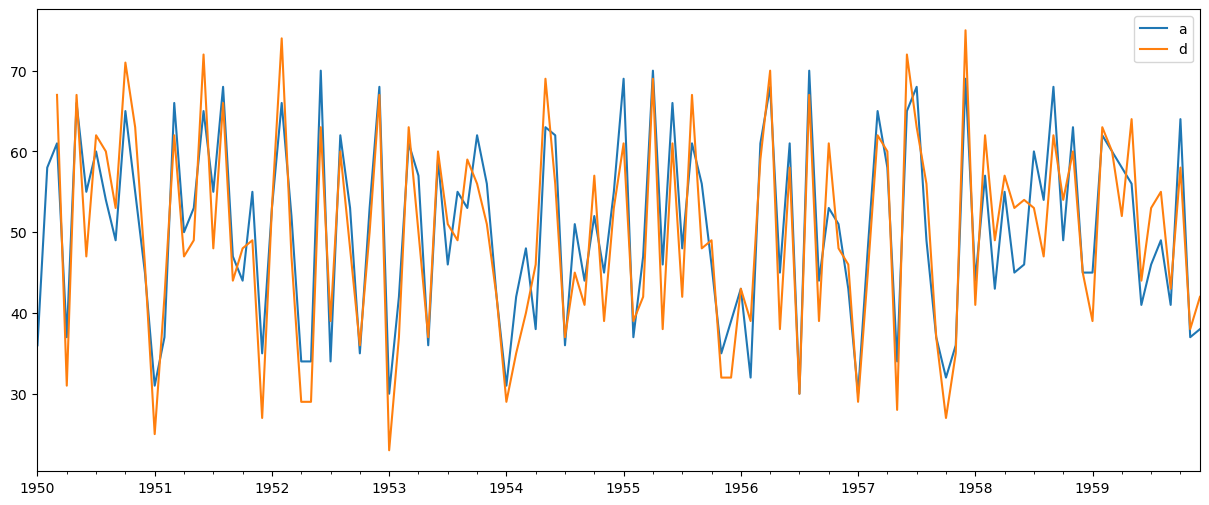

In [26]:
# Plotting 'a' and 'd' shifted by 2 steps:

df['a'].plot(kind= 'line', figsize= (15,6), label= 'a', legend= True)
df['d'].shift(periods= 2).plot(kind= 'line', figsize= (15,6), label= 'd', legend= True)
plt.show()

`Running Causality Test on 'a' and 'd' by using Lag value of 2:`

In [28]:
grangercausalitytests(x= df[['a','d']], maxlag= 2);


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.7051  , p=0.1942  , df_denom=116, df_num=1
ssr based chi2 test:   chi2=1.7492  , p=0.1860  , df=1
likelihood ratio test: chi2=1.7365  , p=0.1876  , df=1
parameter F test:         F=1.7051  , p=0.1942  , df_denom=116, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=286.0339, p=0.0000  , df_denom=113, df_num=2
ssr based chi2 test:   chi2=597.3806, p=0.0000  , df=2
likelihood ratio test: chi2=212.6514, p=0.0000  , df=2
parameter F test:         F=286.0339, p=0.0000  , df_denom=113, df_num=2


`Running Causality Test on 'a' and 'd' by using Lag value of 3:`

In [32]:
grangercausalitytests(x= df[['a', 'd']], maxlag= 3);


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.7051  , p=0.1942  , df_denom=116, df_num=1
ssr based chi2 test:   chi2=1.7492  , p=0.1860  , df=1
likelihood ratio test: chi2=1.7365  , p=0.1876  , df=1
parameter F test:         F=1.7051  , p=0.1942  , df_denom=116, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=286.0339, p=0.0000  , df_denom=113, df_num=2
ssr based chi2 test:   chi2=597.3806, p=0.0000  , df=2
likelihood ratio test: chi2=212.6514, p=0.0000  , df=2
parameter F test:         F=286.0339, p=0.0000  , df_denom=113, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=188.7446, p=0.0000  , df_denom=110, df_num=3
ssr based chi2 test:   chi2=602.2669, p=0.0000  , df=3
likelihood ratio test: chi2=212.4789, p=0.0000  , df=3
parameter F test:         F=188.7446, p=0.0000  , df_denom=110, df_num=3


`Running Causality Test on 'b' and 'd' by using Lag value of 3:`

In [31]:
grangercausalitytests(x= df[['b', 'd']], maxlag= 3);


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.5225  , p=0.2197  , df_denom=116, df_num=1
ssr based chi2 test:   chi2=1.5619  , p=0.2114  , df=1
likelihood ratio test: chi2=1.5517  , p=0.2129  , df=1
parameter F test:         F=1.5225  , p=0.2197  , df_denom=116, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.4350  , p=0.6483  , df_denom=113, df_num=2
ssr based chi2 test:   chi2=0.9086  , p=0.6349  , df=2
likelihood ratio test: chi2=0.9051  , p=0.6360  , df=2
parameter F test:         F=0.4350  , p=0.6483  , df_denom=113, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.5333  , p=0.6604  , df_denom=110, df_num=3
ssr based chi2 test:   chi2=1.7018  , p=0.6365  , df=3
likelihood ratio test: chi2=1.6895  , p=0.6393  , df=3
parameter F test:         F=0.5333  , p=0.6604  , df_denom=110, df_num=3
